In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import ast
#plt.rcParams['font.family'] = 'AppleGothic'    # Mac
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
plt.rcParams['axes.unicode_minus'] = False

reviews = pd.read_csv("../../../data/steam_indie_reviews.csv")

reviews.head()

,recommendationid,appid,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,...,steam_purchase,received_for_free,written_during_early_access,author_steamid,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played
0,134554560,1432860,english,"For me, Sun Haven is a fun farming game that h...",1678643330,1678643330,True,1432,25,0.971922,...,True,False,False,76561199471119493,0,1,4120,0,1723,1763967370
1,135610350,1432860,english,*Updated for v1.0.3*\n\nI really love this gam...,1680018629,1680192211,False,1564,18,0.939696,...,True,False,False,76561198107464933,663,108,12951,0,8605,1690050219
2,136483272,1432860,english,(Singleplayer review)\nPuh i am not really sur...,1681149417,1681149417,True,166,0,0.917131,...,True,False,False,76561198005466151,1021,4,3653,0,3400,1723728962
3,138973732,1432860,russian,"Я наиграла в эту игру почти 55 часов, 40+ из к...",1685034459,1685034459,False,224,7,0.897391,...,True,False,False,76561198098873026,720,16,3280,0,3280,1684534023
4,136801481,1432860,japanese,Sun Haven好きさんが増えると嬉しいので、初めてレビューします。\n\nこれを見たあな...,1681649431,1682154116,True,143,10,0.895801,...,True,False,False,76561199151368353,0,1,12057,0,7849,1723475976


In [24]:
reviews.T

,0,1,2,3,4,5,6,7,8,9,...,13096,13097,13098,13099,13100,13101,13102,13103,13104,13105
recommendationid,134554560,135610350,136483272,138973732,136801481,138390560,137684835,137254967,138940421,138525097,...,154324834,154264500,154261657,154252204,154140989,154134250,154088182,154087725,154082345,154072693
appid,1432860,1432860,1432860,1432860,1432860,1432860,1432860,1432860,1432860,1432860,...,1700300,1700300,1700300,1700300,1700300,1700300,1700300,1700300,1700300,1700300
language,english,english,english,russian,japanese,english,english,japanese,spanish,english,...,english,english,english,english,english,russian,english,english,english,english
review,"For me, Sun Haven is a fun farming game that h...",*Updated for v1.0.3*\n\nI really love this gam...,(Singleplayer review)\nPuh i am not really sur...,"Я наиграла в эту игру почти 55 часов, 40+ из к...",Sun Haven好きさんが増えると嬉しいので、初めてレビューします。\n\nこれを見たあな...,I want to make this short and as to the point ...,TL; DR - No. No. Nonono. Get My Time at Sandro...,[h1]Stardew Valleyの凡庸なクローンに終わらず、ブラッシュアップを感じさせる...,"No es LO MISMO que stardew, es muy similar per...",---{ Graphics }---\n☐ You forget what reality ...,...,I haven't a clue what i'm doing\nI do love the...,"Game is in early access stage, it has very bas...",Solid game and I do realize this is early acce...,Mhh after big update this feels like the same ...,trash game. trash devs. pay for unplayable gar...,Все печально.,Im actually enjoyed playing this game however ...,OK so here's my opinion. The game is still in ...,Rejoice! We finally have Power and Revolution ...,After 31 hours of free playtesting I have to s...
timestamp_created,1678643330,1680018629,1681149417,1685034459,1681649431,1684259883,1683043900,1682388310,1684978681,1684468349,...,1703452654,1703389043,1703385700,1703374772,1703261843,1703255975,1703195683,1703195205,1703189677,1703179704
timestamp_updated,1678643330,1680192211,1681149417,1685034459,1682154116,1684259883,1686754932,1682567921,1684978681,1684468349,...,1709732312,1703389043,1703385700,1740918747,1772937717,1747971290,1703195683,1703195205,1740971830,1709935765
voted_up,True,False,True,False,True,False,False,True,True,True,...,True,True,True,False,False,False,True,True,False,False
votes_up,1432,1564,166,224,143,161,713,64,56,134,...,4,0,0,0,0,0,0,0,0,0
votes_funny,25,18,0,7,10,2,11,1,0,13,...,0,0,0,0,0,0,0,0,0,0
weighted_vote_score,0.971922,0.939696,0.917131,0.897391,0.895801,0.887512,0.883798,0.862564,0.861912,0.846828,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5


긍정리뷰 부정리뷰 뽑기

In [25]:
reviews["sentiment"] = reviews["voted_up"].map({
    True: "positive",
    False: "negative"
})

reviews[["appid", "language", "review", "voted_up", "sentiment"]].head()

,appid,language,review,voted_up,sentiment
0,1432860,english,"For me, Sun Haven is a fun farming game that h...",True,positive
1,1432860,english,*Updated for v1.0.3*\n\nI really love this gam...,False,negative
2,1432860,english,(Singleplayer review)\nPuh i am not really sur...,True,positive
3,1432860,russian,"Я наиграла в эту игру почти 55 часов, 40+ из к...",False,negative
4,1432860,japanese,Sun Haven好きさんが増えると嬉しいので、初めてレビューします。\n\nこれを見たあな...,True,positive


일단 영어리뷰만 뽑기

In [26]:
reviews_en = reviews[
    (reviews["language"] == "english") &
    (reviews["review"].notna())
].copy()

reviews_en.shape

(5338, 22)

긍정리뷰 부정리뷰 샘플 추출

In [27]:
positive_sample = reviews_en[reviews_en["voted_up"] == True].sample(
    20,
    random_state=42
)

negative_sample = reviews_en[reviews_en["voted_up"] == False].sample(
    20,
    random_state=42
)

review_sample = pd.concat([positive_sample, negative_sample])

review_sample[["sentiment", "review"]].head()

,sentiment,review
7944,positive,Actually a lot of fun for an idle slot machine...
7540,positive,This was incredibly fun! Also felt really well...
1192,positive,---{ Graphics }---\n☐ You forget what reality ...
7482,positive,Things this game does well:\n\nBridges the gap...
6666,positive,Fun.


번역기 설치

In [28]:
# uv add deep-translator

영어리뷰를 한국어로 번역하기

In [29]:
from deep_translator import GoogleTranslator
import time

translator = GoogleTranslator(source="en", target="ko")

def translate_to_korean(text):
    try:
        text = str(text)
        
        # 너무 긴 리뷰는 앞부분만 번역
        text = text[:4500]
        
        translated = translator.translate(text)
        time.sleep(0.3)  # 요청 너무 빠르게 보내지 않기
        
        return translated
    
    except Exception as e:
        return f"번역 실패: {e}"

review_sample["review_ko"] = review_sample["review"].apply(translate_to_korean)

review_sample[["sentiment", "review", "review_ko"]].head()

,sentiment,review,review_ko
7944,positive,Actually a lot of fun for an idle slot machine...,실제로 방치형 슬롯머신 RPG 로그라이크 치고는 정말 재미있습니다. 아직 개발 초기...
7540,positive,This was incredibly fun! Also felt really well...,정말 재미있었어요! 또한 타이탄과 PC 플레이어 모두가 승리할 수 있는 공평한 기회...
1192,positive,---{ Graphics }---\n☐ You forget what reality ...,---{ 그래픽 }---\n☐ 현실이 무엇인지 잊어버린 당신\n☐ 아름다운\n✓ 좋...
7482,positive,Things this game does well:\n\nBridges the gap...,이 게임의 장점:\n\nVR이 있는 친구와 그렇지 않은 친구 사이의 격차를 해소합니...
6666,positive,Fun.,재미있는.


긍정리부 정리

In [30]:
positive_translated = review_sample[
    review_sample["sentiment"] == "positive"
][["sentiment", "review", "review_ko"]]

positive_translated.head(10)

,sentiment,review,review_ko
7944,positive,Actually a lot of fun for an idle slot machine...,실제로 방치형 슬롯머신 RPG 로그라이크 치고는 정말 재미있습니다. 아직 개발 초기...
7540,positive,This was incredibly fun! Also felt really well...,정말 재미있었어요! 또한 타이탄과 PC 플레이어 모두가 승리할 수 있는 공평한 기회...
1192,positive,---{ Graphics }---\n☐ You forget what reality ...,---{ 그래픽 }---\n☐ 현실이 무엇인지 잊어버린 당신\n☐ 아름다운\n✓ 좋...
7482,positive,Things this game does well:\n\nBridges the gap...,이 게임의 장점:\n\nVR이 있는 친구와 그렇지 않은 친구 사이의 격차를 해소합니...
6666,positive,Fun.,재미있는.
6631,positive,"Good fun, vampire survivor clone with RPG elem...",RPG 요소가 포함된 매우 재미있는 뱀파이어 생존자 클론입니다. 스팀덱에서 재미있는...
9673,positive,Great game. alot of micromanagement however. I...,훌륭한 게임. 그러나 많은 마이크로매니지먼트. 나는 이런 인디 게임을 좋아한다. 3...
6187,positive,"This was the funniest ""horror"" game I've ever ...","이것은 내가 해본 것 중 가장 재미있는 ""공포"" 게임이었습니다. 형편없는 문법은 정..."
1931,positive,Super fun if you put on scenario and then eart...,시나리오를 깔고 지구를 깔면 정말 재미있어요\n확실히 내 돈 가치가 있어
9859,positive,I've been playing this game for a few years on...,나는 몇 년 동안 이 게임을 온/오프로 플레이해 왔습니다(스팀에서는 아님). 나는 ...


부정리뷰 정리

In [31]:
negative_translated = review_sample[
    review_sample["sentiment"] == "negative"
][["sentiment", "review", "review_ko"]]

negative_translated.head(10)

,sentiment,review,review_ko
9194,negative,I wanted to like this a lot more than I did. I...,나보다 이걸 더 좋아하고 싶었다. 포인트 앤 클릭 방식의 미스터리물을 보고 싶었는데...
10039,negative,i played this game for 47 minutes and requeste...,나는 이 게임을 47분 동안 플레이했고 환불을 요청했습니다. 이제 게임은 시간을 보...
4012,negative,"BIG CAVEAT: about halfway through, this stops ...",큰 주의 사항: 중간쯤 지나면 점술의 재미에 관한 것이 아니라 핵심적이고 세부적인 ...
9363,negative,Starts off really strong but suffers from some...,처음에는 매우 강력하게 시작하지만 나중에는 다소 정체성 위기를 겪습니다.\n\n게임...
4601,negative,-Bought the game 2 weeks before 1.0.9\n-Played...,-1.0.9 2주 전에 게임을 구매했습니다.\n- 약 120시간 정도 플레이했습니다...
2397,negative,"(This isn't meant to be a negative review, it'...",(부정적인 리뷰가 아니라 혼합된 리뷰입니다.)\n\nTiny Glade는 정말 화려...
6602,negative,Extremely disappointed with this game. I was e...,이 게임에 매우 실망했습니다. 나는 Pathfinder를 기반으로 한 Vampire...
924,negative,Fun at the beginning but the other review was ...,처음에는 재미 있었지만 다른 리뷰는 옳았습니다. 그것은 보스 싸움의 갈기와 보스와 ...
8201,negative,"Presentation is good, but the personality test...",프리젠테이션은 좋지만 인성검사 측면 자체가 버즈피드 인성검사처럼 꽤 얕습니다.
3269,negative,I'm not really sure what the thought behind th...,새로운 콘텐츠 뒤에 숨은 생각이 무엇인지 잘 모르겠습니다. 모든 것이 정말 짜증나고...


리뷰 총 정리

In [32]:
for idx, row in review_sample.iterrows():
    print("=" * 80)
    print("감성:", row["sentiment"])
    print("\n[원문]")
    print(row["review"][:1000])
    print("\n[한국어 번역]")
    print(row["review_ko"][:1000])

감성: positive

[원문]
Actually a lot of fun for an idle slot machine RPG roguelike. It's still pretty early in development and is a bit unbalanced and slightly light on content, but man, it's very satisfying. Can't wait to see what else the dev has cooking, because the foundation so far is solid and is a great concept.

[한국어 번역]
실제로 방치형 슬롯머신 RPG 로그라이크 치고는 정말 재미있습니다. 아직 개발 초기 단계이고 약간 불균형하고 내용도 약간 가볍지만, 매우 만족스럽습니다. 지금까지의 기초가 탄탄하고 훌륭한 개념이기 때문에 개발자가 또 무엇을 요리하고 있는지 보고 싶습니다.
감성: positive

[원문]
This was incredibly fun! Also felt really well balanced, where both a titan and PC players had a fair chance to win! We were laughing, screaming and crying non-stop!  Devs, you've made something really special! Huge thanks to you for this amazing experience! <3

[한국어 번역]
정말 재미있었어요! 또한 타이탄과 PC 플레이어 모두가 승리할 수 있는 공평한 기회를 가졌기 때문에 균형이 정말 잘 잡혀 있다고 느꼈습니다! 우리는 쉬지 않고 웃고, 비명을 지르고, 울고 있었습니다!  개발자 여러분, 정말 특별한 것을 만드셨습니다! 이 놀라운 경험에 진심으로 감사드립니다! <3
감성: positive

[원문]
---{ Graphics }---
☐ You forget what reality is
☐ Bea

In [33]:
reviews.groupby("voted_up")["author_playtime_forever"].median()

#True는 긍정
#False는 부정

voted_up
False    422.0
True     725.0
Name: author_playtime_forever, dtype: float64

심층분석

필요한 컬럼만 추출

In [34]:
reviews[[
    "appid",
    "language",
    "review",
    "sentiment",
    "author_playtime_forever",
    "timestamp_created"
]].head()

,appid,language,review,sentiment,author_playtime_forever,timestamp_created
0,1432860,english,"For me, Sun Haven is a fun farming game that h...",positive,4120,1678643330
1,1432860,english,*Updated for v1.0.3*\n\nI really love this gam...,negative,12951,1680018629
2,1432860,english,(Singleplayer review)\nPuh i am not really sur...,positive,3653,1681149417
3,1432860,russian,"Я наиграла в эту игру почти 55 часов, 40+ из к...",negative,3280,1685034459
4,1432860,japanese,Sun Haven好きさんが増えると嬉しいので、初めてレビューします。\n\nこれを見たあな...,positive,12057,1681649431


긍정과 부정의 비율 보기

In [35]:
sentiment_ratio = reviews["sentiment"].value_counts(normalize=True) * 100
sentiment_ratio.round(2)

sentiment
positive    78.9
negative    21.1
Name: proportion, dtype: float64

전체적으로 긍정의 리뷰 비율이 높음

리뷰의 길이

In [36]:
reviews["review_length"] = reviews["review"].astype(str).str.len()

reviews[["review", "sentiment", "review_length"]].head()

,review,sentiment,review_length
0,"For me, Sun Haven is a fun farming game that h...",positive,652.0
1,*Updated for v1.0.3*\n\nI really love this gam...,negative,7710.0
2,(Singleplayer review)\nPuh i am not really sur...,positive,1317.0
3,"Я наиграла в эту игру почти 55 часов, 40+ из к...",negative,7999.0
4,Sun Haven好きさんが増えると嬉しいので、初めてレビューします。\n\nこれを見たあな...,positive,1257.0


긍정과 부정의 리뷰의 길이를 봐보자

In [37]:
length_summery = (
    reviews.groupby('sentiment')['review_length']
    .describe()
)
length_summery

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,2766.0,667.079537,1095.701550,1.0,113.0,282.0,726.0,7999.0
positive,10338.0,495.947379,810.202687,1.0,99.0,238.0,527.0,7999.0


대체적으로 부정리뷰의 길이가 더 긴것을 확인할 수있음

중앙값으로 봐보면

In [38]:
reviews.groupby('sentiment')['review_length'].median()

sentiment
negative    282.0
positive    238.0
Name: review_length, dtype: float64

** 즉 부정적인 리뷰를 남긴 유저가 좀더 자세한 리뷰를 남겻을 가능성을 보임

리뷰 길이 시각화

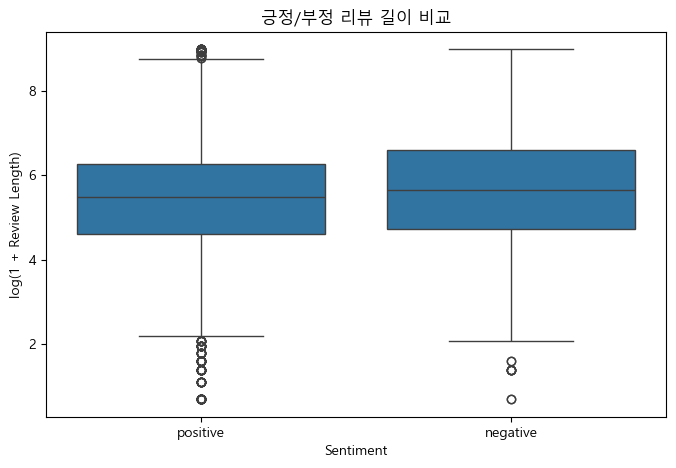

In [39]:
reviews["log_review_length"] = np.log1p(reviews["review_length"])

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=reviews,
    x="sentiment",
    y="log_review_length"
)

plt.title("긍정/부정 리뷰 길이 비교")
plt.xlabel("Sentiment")
plt.ylabel("log(1 + Review Length)")
plt.show()

플레이 타임을 전처리

In [41]:
reviews["playtime_hours"] = (reviews["author_playtime_forever"] / 60).round(2)

reviews[["author_playtime_forever", "playtime_hours"]].head()

,author_playtime_forever,playtime_hours
0,4120,68.67
1,12951,215.85
2,3653,60.88
3,3280,54.67
4,12057,200.95


긍정과 부정별 플레이타임 비교

In [42]:
playtime_summary = (
    reviews.groupby("sentiment")["playtime_hours"]
    .describe()
)

playtime_summary

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,2766.0,53.057144,285.688676,0.08,2.02,7.030,21.365,7479.77
positive,10340.0,47.207232,179.387338,0.08,4.68,12.085,32.920,5221.40


중앙값만 보기

In [43]:
reviews.groupby("sentiment")["playtime_hours"].median()

sentiment
negative     7.030
positive    12.085
Name: playtime_hours, dtype: float64

플레이 타임의 극단값이 너무 커서 로그변환 진행 후 시각화

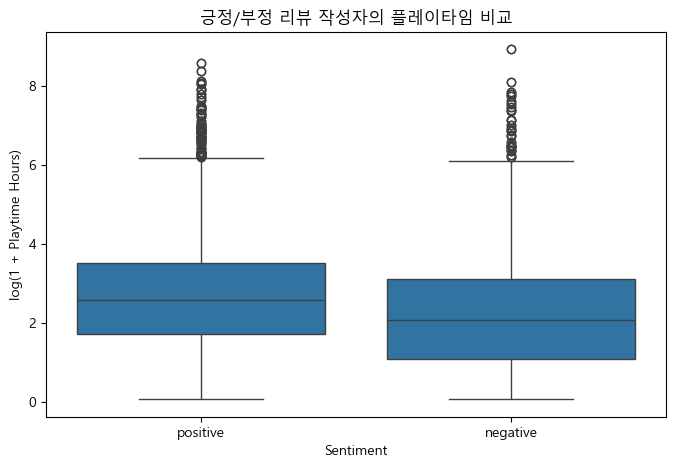

In [44]:
reviews["log_playtime_hours"] = np.log1p(reviews["playtime_hours"])

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=reviews,
    x="sentiment",
    y="log_playtime_hours"
)

plt.title("긍정/부정 리뷰 작성자의 플레이타임 비교")
plt.xlabel("Sentiment")
plt.ylabel("log(1 + Playtime Hours)")
plt.show()

언어의 분포 확인

In [45]:
language_summary = (
    reviews["language"]
    .value_counts()
    .reset_index()
)

language_summary.columns = ["language", "review_count"]
language_summary.head(20)

,language,review_count
0,english,5340
1,schinese,3570
2,russian,764
3,japanese,560
4,koreana,488
5,brazilian,478
6,spanish,382
7,tchinese,364
8,french,276
9,german,212


시각화

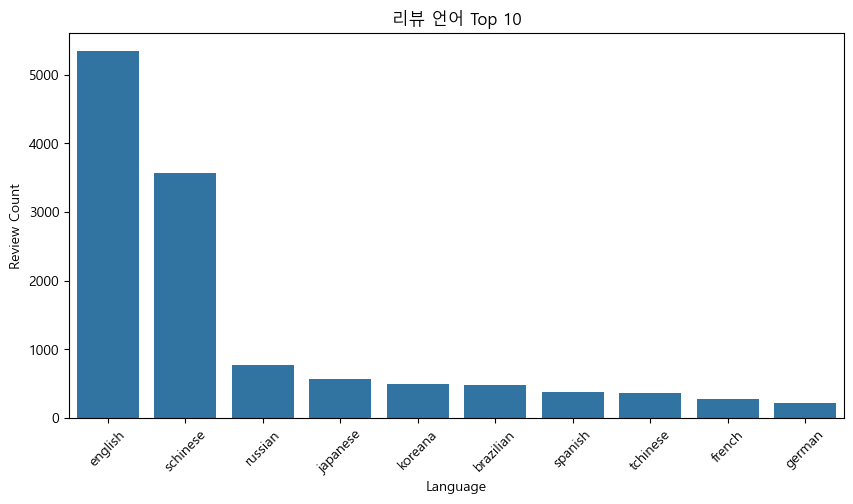

In [46]:
top_lang = reviews["language"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_lang.index,
    y=top_lang.values
)

plt.title("리뷰 언어 Top 10")
plt.xlabel("Language")
plt.ylabel("Review Count")
plt.xticks(rotation=45)
plt.show()

언어별 긍정율 비율

In [47]:
lang_sentiment = (
    reviews.groupby("language")
    .agg(
        review_count=("review", "count"),
        positive_ratio=("voted_up", "mean")
    )
    .sort_values("review_count", ascending=False)
)

lang_sentiment.head(20)

,review_count,positive_ratio
language,,
english,5338,0.787266
schinese,3570,0.760224
russian,764,0.790576
japanese,560,0.807143
koreana,488,0.778689
brazilian,478,0.899582
spanish,382,0.963351
tchinese,364,0.725275
french,276,0.920290


언어는 너무다양하기때문에 30개이상의 리뷰가 있는 리뷰만봐보자

In [48]:
lang_sentiment_30 = lang_sentiment[
    lang_sentiment["review_count"] >= 30
].copy()

lang_sentiment_30.sort_values("positive_ratio", ascending=False)

,review_count,positive_ratio
language,,
spanish,382,0.963351
latam,100,0.940000
french,276,0.920290
thai,48,0.916667
brazilian,478,0.899582
polish,72,0.888889
turkish,138,0.869565
japanese,560,0.807143
italian,30,0.800000


시각화

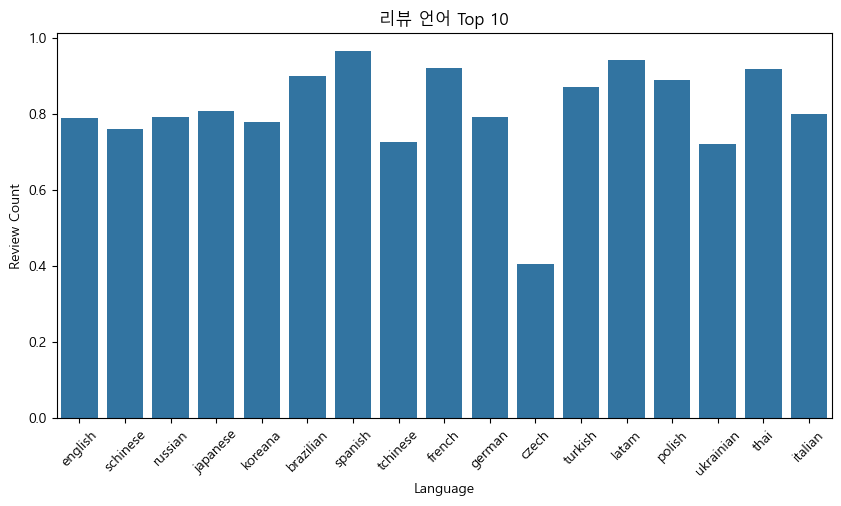

In [51]:
pos_ratio = lang_sentiment_30

plt.figure(figsize=(10, 5))
sns.barplot(data = pos_ratio , x = 'language',y = 'positive_ratio')

plt.title("리뷰 언어 Top 10")
plt.xlabel("Language")
plt.ylabel("Review Count")
plt.xticks(rotation=45)
plt.show()

시간칼럼 변화

In [52]:
reviews["created_date"] = pd.to_datetime(
    reviews["timestamp_created"],
    unit="s",
    errors="coerce"
)

reviews["created_month"] = reviews["created_date"].dt.to_period("M").astype(str)

reviews[["timestamp_created", "created_date", "created_month"]].head()

,timestamp_created,created_date,created_month
0,1678643330,2023-03-12 17:48:50,2023-03
1,1680018629,2023-03-28 15:50:29,2023-03
2,1681149417,2023-04-10 17:56:57,2023-04
3,1685034459,2023-05-25 17:07:39,2023-05
4,1681649431,2023-04-16 12:50:31,2023-04


In [53]:
monthly_review = (
    reviews.groupby("created_month")
    .agg(
        review_count=("review", "count"),
        positive_ratio=("voted_up", "mean")
    )
    .reset_index()
)

monthly_review.head()

,created_month,review_count,positive_ratio
0,2023-02,396,0.904040
1,2023-03,180,0.844444
2,2023-04,224,0.857143
3,2023-05,450,0.680000
4,2023-06,188,0.723404


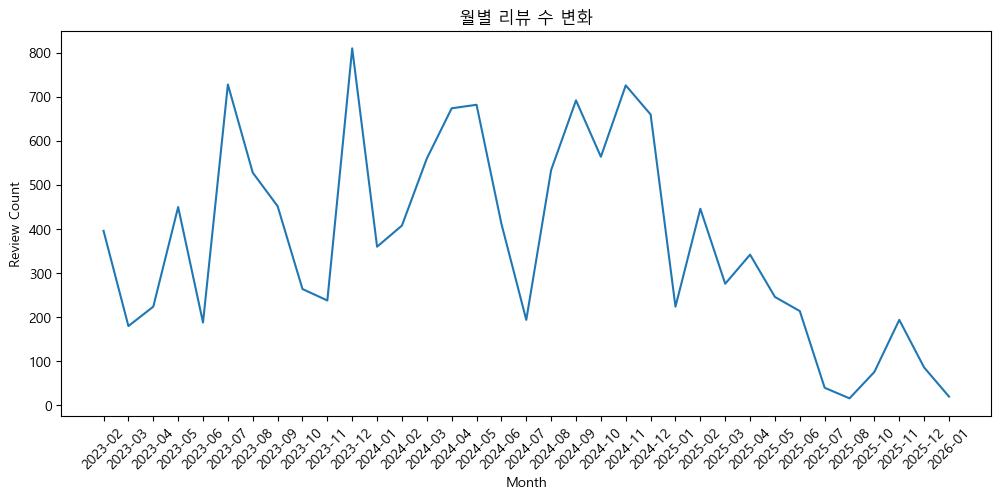

In [56]:
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_review,
    x="created_month",
    y="review_count"
)

plt.title("월별 리뷰 수 변화")
plt.xlabel("Month")
plt.ylabel("Review Count")
plt.xticks(rotation=45)
plt.show()

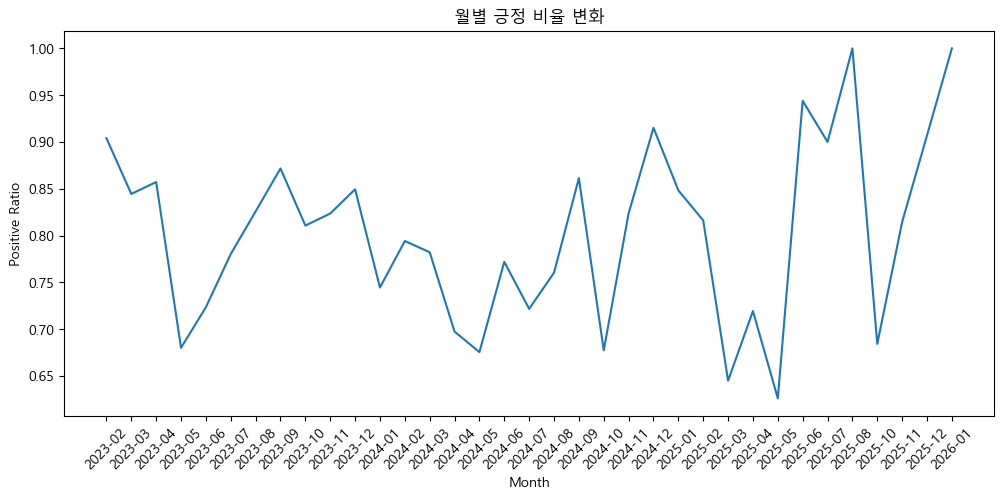

In [58]:
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_review,
    x="created_month",
    y="positive_ratio"
)

plt.title("월별 긍정 비율 변화")
plt.xlabel("Month")
plt.ylabel("Positive Ratio")
plt.xticks(rotation=45)
plt.show()

전체 리뷰 중 긍정 리뷰 비율은 약 78.9%로 나타났다.
부정 리뷰는 긍정 리뷰보다 리뷰 길이 중앙값이 길었고, 이는 불만 유저가 더 구체적인 문제를 작성했을 가능성을 보여준다.
플레이타임 기준으로는 부정 리뷰 작성자의 중앙 플레이타임이 더 높았다.
언어별로는 영어 리뷰가 가장 많았으며, 리뷰 수 30개 이상 언어 중 스페인 언어의 긍정 비율이 가장 높았다.